# Basic setup

In [10]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import TTestPower
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

In [11]:
sns.set_theme(style="whitegrid", palette="Set2")

In [21]:
data = pd.DataFrame()
data = load_penguins()

# Exploration

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


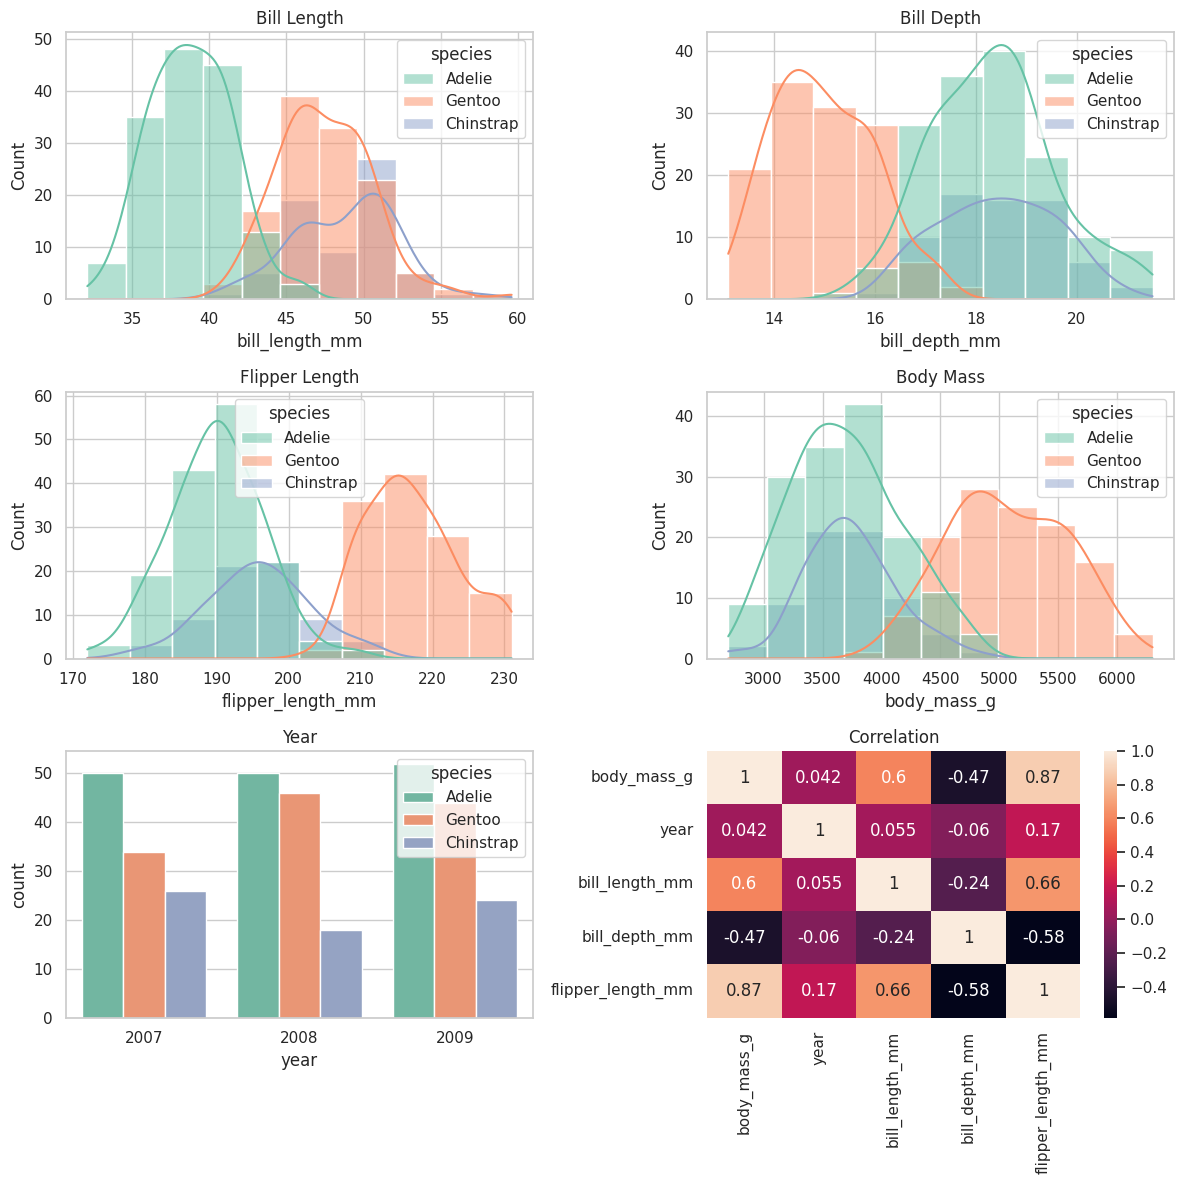

In [14]:
# Ax level plots

fig, ax = plt.subplots(3, 2, figsize=(12, 12))

sns.histplot(data, x="bill_length_mm", hue="species", kde=True, ax=ax[0,0])
ax[0,0].set_title('Bill Length')

sns.histplot(data, x="bill_depth_mm", hue="species", kde=True, ax=ax[0,1])
ax[0,1].set_title('Bill Depth')

sns.histplot(data, x="flipper_length_mm", hue="species", kde=True, ax=ax[1,0])
ax[1,0].set_title('Flipper Length')

sns.histplot(data, x="body_mass_g", hue="species", kde=True, ax=ax[1,1])
ax[1,1].set_title('Body Mass')

sns.countplot(data, x="year", hue="species", ax=ax[2,0])
ax[2,0].set_title('Year')

sns.heatmap(data.loc[:, ['body_mass_g', 'year', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].corr(), annot=True, ax=ax[2,1])
ax[2,1].set_title('Correlation')

plt.tight_layout()
plt.show()

# Experiments

## Statistical power

An A/B testing experiment is being developed to see if a new diet could increase the weight of the Adelie species by 100 grams. What is the statistical power if we can only sample 200 penguins?

In [15]:
# Adelie species parameters
ade_mean = np.mean(data.query('species == "Adelie"').body_mass_g)
ade_std = np.std(data.query('species == "Adelie"').body_mass_g, ddof=1) # degree of freedom = n - 1 since we are using the sample from the dataset
alpha = 0.05
target_weight = 3800
sample = 200

In [16]:
# Manual calculation

sem = ade_std / np.sqrt(sample)
x_critical = ade_mean + sem * stats.t.ppf(1 -alpha, df=sample - 1)
t_score = (x_critical - target_weight) / sem
power = stats.t.sf(t_score, df=sample - 1)

print(f'The statistical power is {power:.4%}')

The statistical power is 92.0100%


If the A/B experiment's goal is to identify a small difference in weight, the number of samples would have to be higher

In [17]:
# Using the package

# One important difference is that the Cohen's d must be calculatted
cohen_d = float((target_weight - ade_mean) / ade_std)

# Calculating the statistical power
power_analysis = TTestPower()
solution = power_analysis.solve_power(effect_size=cohen_d, nobs=sample, alpha=alpha, alternative='larger')
print(f'The statistical power is {solution:.4%}')

# If I would like to know the sample size based on a desired power of 80%
sample_size = power_analysis.solve_power(power=0.90, effect_size=cohen_d, alpha=alpha, alternative='larger')
print(f'\nThe sample size required is {sample_size:.0f}')

The statistical power is 92.0475%

The sample size required is 184


## Hypothesis testing

### Hypothesis testing of the mean - one sample

In the 90's, the average gentoo penguin weight was 4.9 Kg. Has this change based on the sample?

In [63]:
# Manual calculation
gentoo_mean = data.query('species == "Gentoo"').body_mass_g.mean()
print(f'The average Gentoo penguin weight was {gentoo_mean:,.2f} grams')
gentoo_size = data.query('species == "Gentoo"').shape[0]
gentoo_std = np.std(data.query('species == "Gentoo"').body_mass_g, ddof=1)
h0 = 4900

sem = gentoo_std / np.sqrt(gentoo_size)
t_test = (gentoo_mean - h0) / sem
p_value = stats.t.sf(np.abs(t_test), df=size - 1) * 2 # Two-sided test
print(f'The p-value is {p_value:.4%}. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from {h0} grams.')


The average Gentoo penguin weight was 5,076.02 grams
The p-value is 0.0164%. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from 4900 grams.


In [62]:
# Using the package

t_stat, p_value = stats.ttest_1samp(a=data.query('species == "Gentoo"')['body_mass_g'].dropna(), popmean=4900, alternative='two-sided')
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is 3.872350495988591 and the p_value is 0.0175%.


Hence, H0 is rejected and the average weight of the Gentoo penguins has changes since the 90s

In [48]:
# Just in case, checking the statistical power
# THIS IS A WRONG APPROACH AS THE SAMPLE DATA IS BEING USED. INSTEAD, THE CONFIDENCE INTERVAL COULD BE EFFECTIVE

cohen_d = float(gentoo_mean - h0) / gentoo_std

# Calculating the statistical power
power_analysis = TTestPower()
statistical_power = power_analysis.solve_power(effect_size=cohen_d, nobs=gentoo_size, alpha=0.05, alternative='two-sided')
print(f'The statistical power is {statistical_power:.4%}.')

The statistical power is 97.1123%.


### Hypothesis testing of the mean- Two samples

This test is basially to understand if wheter 2 samples come from the same population

Is there a statistically significant difference in the average body mass of Adelie penguins living on Torgersen Island compared to those on Biscoe Island?

In [68]:
sample1 = data[(data.species == 'Adelie') & (data.island == 'Torgersen')].body_mass_g.dropna()
sample2 = data[(data.species == 'Adelie') & (data.island == 'Biscoe')].body_mass_g.dropna()

t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False, alternative='two-sided')
# equal_var = False means to use Welch's t-test' which does not assume equal variance
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is -0.034096013235371626 and the p_value is 97.2878%.


These 2 samples from Adelie penguins from two different islands show that they come from the population as there is no significant difference in their average eight

## Linear regression

## Classification

# DRAFT

In [61]:
data[data.body_mass_g.isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [31]:
data.query('species == "Gentoo"').shape[0]

124

In [19]:
data.query('species == "Adelie"').body_mass_g.mean()

np.float64(3700.662251655629)